# Silicon Photovoltaic Solar Cell Model

This notebook provides a fluid-agnostic, open-source Python implementation of a photovoltaic (PV) array generator based on a high-fidelity **equivalent circuit one-diode model**. 

The code evaluates electrical output implicitly using non-linear transcendental equations alongside a transient **dynamic thermal lumped capacitance model** to resolve real-time operating cell temperatures ($T_{\text{cell}}$).

## 🔬 Modeling Architecture & State Points
The engine models the standard equivalent electrical framework:
* **Photocurrent generation ($I_L$):** Linearly bound to shifting incident irradiance.
* **Diode Saturation Interterface ($I_D$):** Dictates non-linear shock-losses across the p-n junction.
* **Lumped Thermal Balance:** Tracks transient temperature trajectories ($C_t \frac{dT}{dt}$) under changing radiative inputs.

# 🔬 Scholarly Reference Link
The underlying mathematical architecture and parameters are verified against the design criteria utilized in:
* **Boodaghi, H.**, et al. (2026). *"Achieving holistic sustainability in solar-hydrogen systems: A 6E-based multi-objective optimization of a PV–PEMFC–PEME–ORC integrated framework."* **Thermal Science and Engineering Progress**. https://doi.org/10.1016/j.tsep.2026.104773

---

### ⚙️ Core Thermodynamic & Electrical Modeling Assumptions
1. **Uniform Temperature Field:** The entire photovoltaic module laminate is modeled as a single lumped thermal capacitance mass ($C_t$), assuming uniform internal thermal conductivity ($\nabla T = 0$).
2. **Stable Parasitic Shunt:** Shunt resistance ($R_{\text{sh}}$) accounts for crystalline edge leakage and is treated as an independent constant under minor temperature shifts.
3. **Ideal Semiconductor Boundary:** Band gap energy boundaries ($e_{\text{gap}} = 1.12\text{ eV}$) remain unshifted across localized ambient variance.
4. **Isothermal Series Resistance:** Internal grid-wire ohmetic series resistance ($R_s$) is assumed decoupled from shifting local array profiles.

In [18]:
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Enforce clean academic plot profiles
plt.style.use('ggplot')

print("--- Cell 1: Scientific Optimization Engine Initialized Natively ---")

--- Cell 1: Scientific Optimization Engine Initialized Natively ---


# 1. Component Boundaries & Ambient Real-Time Inputs
Initializes the reference cell conditions ($\text{STC}$: $1000\text{ W/m}^2$, $298\text{ K}$) alongside localized, real-time transient environmental metrics captured from the paper's default baseline state.

In [19]:
# =============================================================================
# 1. INPUT PARAMETERS & MODULE BOUNDARY CONDITIONS (SI UNITS)
# =============================================================================

# ---------- Semiconductor & Cell Reference Constants ----------
e_gap       = 1.12           # Silicon band gap energy barrier [eV]
N_s         = 36             # Number of solar cells linked in stack series [-]
I_sc_ref    = 4.0            # Reference short-circuit current limit [A]
U_oc_ref    = 21.3           # Reference open-circuit voltage limit [V]
T_cell_ref  = 298.0          # Reference cell temperature state [K] (25 °C)
G_T_ref     = 1000.0         # Reference incident solar irradiance flux [W/m²]
I_mp_ref    = 3.66           # Reference current output at maximum power point [A]
U_mp_ref    = 17.5           # Reference voltage output at maximum power point [V]

# ---------- Dynamic Temperature Scaling Modifiers ----------
mu_Isc      = 3e-3           # Short-circuit current thermal coefficient [A/K]
mu_Uoc      = -0.073         # Open-circuit voltage thermal coefficient [V/K]
R_sh        = 1000.0         # Array internal shunt parallel resistance [Ohms]

# ---------- Array Geometry & NOCT Structural Benchmarks ----------
W           = 0.5016         # Photovoltaic module width metric [m]
L           = 1.1082         # Photovoltaic module length metric [m]
A_cell      = W * L          # Net radiative capture surface area [m²]
T_c_NOCT    = 273.15 + 49.0  # Nominal Operating Cell Temperature threshold [K]
G_T_NOCT    = 800.0          # Incident solar irradiance at NOCT benchmark [W/m²]
T_amb_NOCT  = 273.15 + 20.0  # Ambient air fluid temperature at NOCT [K]
taualpha    = 0.9            # Laminate trans-absorptance parameter product [-]

# ---------- Dynamic Environmental & Operational Inputs ----------
U_cell      = 24.393 / 2.0   # Assigned system operating point voltage state [V]
G_T         = 1000.0         # Incident real-world solar radiation flux [W/m²]
T_amb       = 273.15 + 19.7  # Real-time ambient fluid atmospheric temperature [K]
T_cell_ini  = 273.15 + 20.0  # Initial module core starting temperature state [K]
DELT        = 60.0           # Discretized integration time execution window [s]
C_t         = 100000.0       # Lumped thermal capacitance factor [J/K]

print("--- Cell 2: System Specifications & Environmental Bounds Injected ---")

--- Cell 2: System Specifications & Environmental Bounds Injected ---


# 2. Reference State Intrinsic Property Resolution
Computes baseline junction parameters including diode reverse saturation thresholds ($I_{o,\text{ref}}$) and curve parameters prior to entering active operational time sweeps.

In [20]:
# =============================================================================
# 2. INTRINSIC CONSTANTS RESOLUTION
# =============================================================================
I_L_ref = I_sc_ref           # Equate starting light current directly to STC short circuit current

# Curve fitting parameter at reference states
a_ref = (mu_Uoc * T_cell_ref - U_oc_ref + e_gap * N_s) / ((mu_Isc * T_cell_ref / I_L_ref) - 3.0)

# Diode reverse saturation threshold current
I_o_ref = I_L_ref * np.exp(-U_oc_ref / a_ref)

# Crystalline grid series resistance (assumed uniform over thermal fluctuations)
R_s = (a_ref * np.log(1.0 - I_mp_ref / I_L_ref) - U_mp_ref + U_oc_ref) / I_mp_ref

print("--- Cell 3: Material Intrinsic States Resolved Successfully ---")
print(f"  Diode Fitting Factor (a_ref)     : {a_ref:.4f} V")
print(f"  Saturation Current   (I_o_ref)   : {I_o_ref:.4e} A")
print(f"  Series Resistance    (R_s)       : {R_s:.4f} Ohms")

--- Cell 3: Material Intrinsic States Resolved Successfully ---
  Diode Fitting Factor (a_ref)     : 0.9847 V
  Saturation Current   (I_o_ref)   : 1.6136e-09 A
  Series Resistance    (R_s)       : 0.3750 Ohms


# 3. Coupled Algebraic-Differential Solver Engine
Contains the core mathematical models: the implicit transcendental root-finding functions for the single-diode loop alongside the first-order ordinary differential equations tracking transient thermal breakdown.

In [21]:
# =============================================================================
# 3. COUPLED MULTI-PHYSICS SIMULATION FUNCTION CORES
# =============================================================================

def electrical_model(T_cell, U, G):
    """
    Evaluates the implicit transcendental single-diode circuit network.
    Returns: Current Output [A], Instantaneous Power [W], and First-Law Electrical Efficiency [-].
    """
    if G <= 0.0:
        return 0.0, 0.0, 0.0
        
    # Recalculate cell parameters matching localized temperature changes
    a = a_ref * (T_cell / T_cell_ref)
    I_o = I_o_ref * (T_cell / T_cell_ref)**3 * np.exp((e_gap * N_s / a_ref) * (1.0 - T_cell_ref / T_cell))
    I_L = (G / G_T_ref) * (I_L_ref + mu_Isc * (T_cell - T_cell_ref))
    
    # Implicit Algebraic Residual Formulation: f(I) = 0
    def current_equation(I):
        I_sh = (U + I * R_s) / R_sh
        I_D = I_o * (np.exp((U + I * R_s) / a) - 1.0)
        return I - (I_L - I_D - I_sh)
        
    # Execute numerical solver using light current as robust starting pivot
    I_cell_initial_guess = I_L 
    I_cell = fsolve(current_equation, I_cell_initial_guess)[0]
    
    # Track performance output vectors
    P_cell = I_cell * U
    eta = P_cell / (A_cell * G)
    
    return I_cell, P_cell, eta

def thermal_derivative(t, T_array):
    """ Computes the transient first-law energy matrix derivative dT/dt """
    T_cell = T_array[0]
    
    # Extract instantaneous operating efficiency from the electrical module
    _, _, eta = electrical_model(T_cell, U_cell, G_T)
    
    # Map global array heat loss coefficients using NOCT reference benchmarks
    U_L = taualpha * G_T / (T_c_NOCT - T_amb_NOCT)
    
    # Quantify transient energy balance vectors [W]
    Q_dot_rad  = taualpha * G_T
    Q_dot_el   = eta * G_T
    Q_dot_loss = U_L * (T_cell - T_amb)
    
    dTdt = (Q_dot_rad - Q_dot_el - Q_dot_loss) / C_t
    return [dTdt]

print("--- Cell 4: Coupled Multi-Physics Modeling Core Fully Compiled ---")

--- Cell 4: Coupled Multi-Physics Modeling Core Fully Compiled ---


# 4. Numerical Time Integration Execution
Solves the initial value problem for the lumped capacitance framework via an adaptive-step Runge-Kutta solver (`RK45`) to pinpoint the accurate operational temperature state.

In [22]:
# =============================================================================
# 4. TRANSIENT SOLUTION COMPILATION
# =============================================================================
t_span = (0.0, DELT)
t_eval = np.linspace(0.0, DELT, 100)

# Run solver
solution = solve_ivp(
    fun=thermal_derivative, 
    t_span=t_span, 
    y0=[T_cell_ini], 
    t_eval=t_eval,
    method='RK45'
)

T_cell_sol   = solution.y[0]
final_T_cell = T_cell_sol[-1]

print(f"==================================================")
print(f"      PV ARRAY CONVERGENCE PERFORMANCE SUMMARY    ")
print(f"==================================================")
print(f"Initial Starting Module Temperature: {T_cell_ini - 273.15:.2f} °C")
print(f"Final Converged Core Temperature   : {final_T_cell - 273.15:.2f} °C (at t={DELT}s)")
print(f"==================================================")

      PV ARRAY CONVERGENCE PERFORMANCE SUMMARY    
Initial Starting Module Temperature: 20.00 °C
Final Converged Core Temperature   : 20.48 °C (at t=60.0s)


# 5. Diagnostic Characteristic Sweeps
Sweeps terminal loading options to print out crisp, research-grade dual-axis $I-V$ and $P-V$ diagnostic visualizations mapping tracking boundaries.

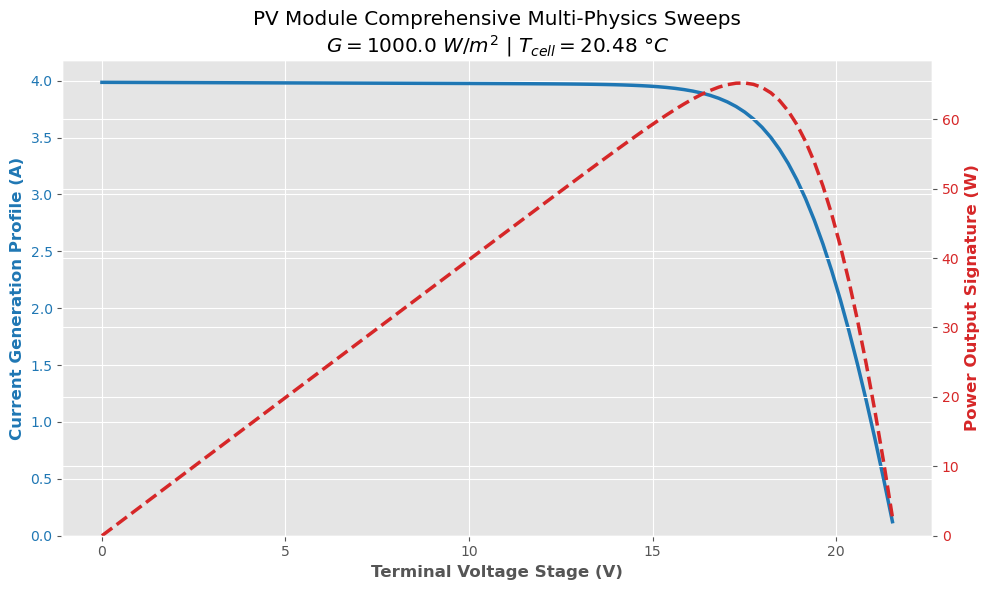

     PV MODULE CRITICAL VALIDATION METRICS        
Environmental Irradiance (G_T) : 1000.0 W/m²
Converged Cell Temperature     : 20.48 °C
--------------------------------------------------
Assigned Operating Voltage     : 12.197 V
Realized Current at Op Point   : 3.972 A
Realized Power Output at Op    : 48.45 W
Electrical Efficiency at Op    : 8.72 %
--------------------------------------------------
Calculated Maximum Power (P_mp): 65.21 W
Calculated Voltage at MPP (V_mp): 17.51 V
Calculated Current at MPP (I_mp): 3.72 A
Approximate Curve Fill Factor (FF): 76.54 %


In [23]:
# =============================================================================
# 5. HIGH-RESOLUTION CHARACTERISTIC SWEEPS & VALIDATION REPORT
# =============================================================================
voltages = np.linspace(0.0, U_oc_ref * 1.1, 100)
currents = []
powers   = []

for v in voltages:
    i, p, _ = electrical_model(final_T_cell, v, G_T)
    currents.append(i)
    powers.append(p)

currents = np.array(currents)
powers   = np.array(powers)

# Discard non-physical negative current values past the open-circuit boundary
valid_idx = currents >= 0.0

# Extract specific critical validation data points for the summary report
I_cell_op, P_cell_op, eta_op = electrical_model(final_T_cell, U_cell, G_T)
P_max_idx = np.argmax(powers)
V_mp_calc = voltages[P_max_idx]
I_mp_calc = currents[P_max_idx]
P_max_calc = powers[P_max_idx]
FF         = (P_max_calc) / (U_oc_ref * I_sc_ref) * 100.0

# ---------- Render High-Resolution Academic Graphics ----------
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Terminal Voltage Stage (V)', fontweight='bold')
ax1.set_ylabel('Current Generation Profile (A)', color=color, fontweight='bold')
ax1.plot(voltages[valid_idx], currents[valid_idx], color=color, linewidth=2.5, label='I-V Curve')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(bottom=0.0)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Power Output Signature (W)', color=color, fontweight='bold')  
ax2.plot(voltages[valid_idx], powers[valid_idx], color=color, linewidth=2.5, linestyle='--', label='P-V Curve')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(bottom=0.0)

plt.title(f'PV Module Comprehensive Multi-Physics Sweeps\n$G = {G_T}\\ W/m^2$ | $T_{{cell}} = {final_T_cell - 273.15:.2f}\\ \\degree C$')
fig.tight_layout()  
plt.show()

# =============================================================================
# 6. COMPREHENSIVE REPRODUCIBILITY KEY RESULTS REPORT
# =============================================================================
print(f"==================================================")
print(f"     PV MODULE CRITICAL VALIDATION METRICS        ")
print(f"==================================================")
print(f"Environmental Irradiance (G_T) : {G_T:.1f} W/m²")
print(f"Converged Cell Temperature     : {final_T_cell - 273.15:.2f} °C")
print(f"--------------------------------------------------")
print(f"Assigned Operating Voltage     : {U_cell:.3f} V")
print(f"Realized Current at Op Point   : {I_cell_op:.3f} A")
print(f"Realized Power Output at Op    : {P_cell_op:.2f} W")
print(f"Electrical Efficiency at Op    : {eta_op * 100:.2f} %")
print(f"--------------------------------------------------")
print(f"Calculated Maximum Power (P_mp): {P_max_calc:.2f} W")
print(f"Calculated Voltage at MPP (V_mp): {V_mp_calc:.2f} V")
print(f"Calculated Current at MPP (I_mp): {I_mp_calc:.2f} A")
print(f"Approximate Curve Fill Factor (FF): {FF:.2f} %")
print(f"==================================================")